# 01 — Data Understanding

---

| Field | Detail |
|---|---|
| **CRISP-DM Phase** | Phase 2 — Data Understanding |
| **Notebook Goal** | Download the Olist dataset, load all 9 tables, profile each table thoroughly, validate date ranges and join keys, flag all data quality issues, and export a profiling summary artifact |
| **Inputs** | Olist dataset downloaded via `kagglehub` (`olistbr/brazilian-ecommerce`) |
| **Outputs** | `01_profiling_summary.parquet` — row counts, null rates, and key flags for all 9 tables |

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Download via kagglehub](#2-data-download)
3. [Load All 9 Tables](#3-load-all-9-tables)
4. [The customer_id vs customer_unique_id Distinction](#4-customer-identity)
5. [Table-by-Table Profiling](#5-table-profiling)
   - 5.1 Orders
   - 5.2 Order Items
   - 5.3 Order Payments
   - 5.4 Order Reviews
   - 5.5 Customers
   - 5.6 Sellers
   - 5.7 Products
   - 5.8 Geolocation
   - 5.9 Category Name Translation
6. [Date Range Validation](#6-date-range-validation)
7. [Cross-Table Relationship Validation](#7-cross-table-validation)
8. [Distribution Plots — Key Numeric Columns](#8-distribution-plots)
9. [Data Quality Issue Register](#9-data-quality-register)
10. [Export Profiling Summary](#10-export)
11. [Notebook Summary](#11-notebook-summary)

---
## 1. Environment Setup

We begin by importing all required libraries and setting global display and plotting defaults. Every library used in this notebook is documented with its role.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Dataset download ───────────────────────────────────────────────────────────
import kagglehub

# ── Display settings ───────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)

# ── Plot style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_STATE = 42

# ── Output path ────────────────────────────────────────────────────────────────
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment ready.')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')

Environment ready.
  pandas  : 2.3.3
  numpy   : 2.3.5


**Interpretation:** All libraries loaded successfully. `RANDOM_STATE = 42` is set for any future sampling operations in this notebook. The output directory for the Parquet artifact is set to the current working directory — update `OUTPUT_DIR` if your folder structure differs.

---
<a id="2-data-download"></a>
## 2. Data Download via kagglehub

Per project specification, data is downloaded **exclusively via the `kagglehub` library**. No manual CSV downloads are used. `kagglehub` caches the dataset locally after the first download, so subsequent runs will use the cached copy.

> **Prerequisite:** A valid Kaggle API token (`~/.kaggle/kaggle.json`) must be present. If running for the first time, follow the [Kaggle API setup guide](https://www.kaggle.com/docs/api).

In [2]:
# Download the Olist dataset via kagglehub
# On first run: downloads ~45 MB and caches locally
# On subsequent runs: returns the cached path immediately

path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print(f'Dataset path: {path}')

# List all files in the downloaded directory
files = sorted(os.listdir(path))
print(f'\nFiles found ({len(files)} total):')
for f in files:
    fpath = os.path.join(path, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {f:<60}  {size_kb:>8.1f} KB')

Dataset path: /Users/seihavat/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2

Files found (9 total):
  olist_customers_dataset.csv                                     8822.2 KB
  olist_geolocation_dataset.csv                                  59837.8 KB
  olist_order_items_dataset.csv                                  15076.8 KB
  olist_order_payments_dataset.csv                                5641.7 KB
  olist_order_reviews_dataset.csv                                14113.0 KB
  olist_orders_dataset.csv                                       17241.1 KB
  olist_products_dataset.csv                                      2323.7 KB
  olist_sellers_dataset.csv                                        170.6 KB
  product_category_name_translation.csv                              2.6 KB


**Interpretation:** The cell above downloads and caches the Olist dataset, then lists all files found in the downloaded directory with their sizes on disk. We expect to find 9 CSV files corresponding to the 9 relational tables described in `00_business_understanding.ipynb`. If the count differs, flag it before proceeding — unexpected files may indicate a dataset version change or extra metadata files that need to be excluded from the load step.

---
<a id="3-load-all-9-tables"></a>
## 3. Load All 9 Tables

We load all tables with **explicit dtype specifications** for known columns. This prevents pandas from silently inferring incorrect types (e.g. reading a zip code as integer and losing leading zeros, or reading a timestamp as object). Any column not explicitly typed is left to pandas inference and flagged for review.

In [3]:
# ── File path helper ───────────────────────────────────────────────────────────
def fp(filename):
    return os.path.join(path, filename)

# ── Timestamp columns by table ─────────────────────────────────────────────────
# Parsed via parse_dates to ensure datetime64 dtype, not object

# 1. Orders
orders = pd.read_csv(
    fp('olist_orders_dataset.csv'),
    dtype={'order_id': str, 'customer_id': str, 'order_status': str},
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
)

# 2. Order Items
order_items = pd.read_csv(
    fp('olist_order_items_dataset.csv'),
    dtype={'order_id': str, 'product_id': str, 'seller_id': str},
    parse_dates=['shipping_limit_date']
)

# 3. Order Payments — IMPORTANT: multiple rows per order (see Section 5.3)
order_payments = pd.read_csv(
    fp('olist_order_payments_dataset.csv'),
    dtype={'order_id': str, 'payment_type': str}
)

# 4. Order Reviews
order_reviews = pd.read_csv(
    fp('olist_order_reviews_dataset.csv'),
    dtype={'review_id': str, 'order_id': str},
    parse_dates=['review_creation_date', 'review_answer_timestamp']
)

# 5. Customers — IMPORTANT: customer_id is order-scoped; customer_unique_id is persistent
customers = pd.read_csv(
    fp('olist_customers_dataset.csv'),
    dtype={
        'customer_id': str,
        'customer_unique_id': str,
        'customer_zip_code_prefix': str,  # keep as str — leading zeros
        'customer_city': str,
        'customer_state': str
    }
)

# 6. Sellers
sellers = pd.read_csv(
    fp('olist_sellers_dataset.csv'),
    dtype={
        'seller_id': str,
        'seller_zip_code_prefix': str,  # keep as str — leading zeros
        'seller_city': str,
        'seller_state': str
    }
)

# 7. Products
products = pd.read_csv(
    fp('olist_products_dataset.csv'),
    dtype={'product_id': str, 'product_category_name': str}
)

# 8. Geolocation — ~1M rows; join at state level only (see Section 4)
geolocation = pd.read_csv(
    fp('olist_geolocation_dataset.csv'),
    dtype={
        'geolocation_zip_code_prefix': str,
        'geolocation_city': str,
        'geolocation_state': str
    }
)

# 9. Category Name Translation (Portuguese → English)
cat_translation = pd.read_csv(
    fp('product_category_name_translation.csv'),
    dtype={'product_category_name': str, 'product_category_name_english': str}
)

# ── Summary of loaded tables ───────────────────────────────────────────────────
tables = {
    'orders':           orders,
    'order_items':      order_items,
    'order_payments':   order_payments,
    'order_reviews':    order_reviews,
    'customers':        customers,
    'sellers':          sellers,
    'products':         products,
    'geolocation':      geolocation,
    'cat_translation':  cat_translation,
}

print(f'{'Table':<22} {'Rows':>8} {'Columns':>8}')
print('-' * 42)
for name, df in tables.items():
    print(f'{name:<22} {df.shape[0]:>8,} {df.shape[1]:>8}')

Table                      Rows  Columns
------------------------------------------
orders                   99,441        8
order_items             112,650        7
order_payments          103,886        5
order_reviews            99,224        7
customers                99,441        5
sellers                   3,095        4
products                 32,951        9
geolocation            1,000,163        5
cat_translation              71        2


**Interpretation:** The table above confirms how many rows and columns each of the 9 tables contains after loading. Key things to check:
- **`orders`** should be the anchor table (~100K rows). Any significant deviation from expectation warrants a flag.
- **`order_payments`** row count should exceed `orders` — multiple payment rows per order is expected and is the key structural quirk handled in `02_data_preparation.ipynb`.
- **`geolocation`** should be the largest table (~1M rows). Its size is why we join at state level only.
- **`cat_translation`** should be small (~71 rows — one per product category).

All ID columns (order_id, customer_id, product_id, etc.) are explicitly cast to `str` to prevent any numeric coercion. Zip code columns are kept as `str` to preserve leading zeros (e.g. zip code `01001` would become `1001` if read as int).

---
<a id="4-customer-identity"></a>
## 4. The `customer_id` vs `customer_unique_id` Distinction

> ⚠️ **This is the most consequential structural issue in the entire dataset. Read this section carefully before any analysis involving customers.**

### What the Two Fields Mean

| Field | Scope | Behaviour |
|---|---|---|
| `customer_id` | **Order-scoped** | A new `customer_id` is generated for each order placed. The same physical customer placing two orders will have two different `customer_id` values. |
| `customer_unique_id` | **Customer-scoped** | A persistent identifier that links all orders to the same real-world customer, regardless of how many orders they place. |

### Why This Matters

The `customers` table uses `customer_id` as its primary key and links to the `orders` table via `customer_id`. This means:

- **The `customers` table does NOT have one row per customer** — it has one row per order. Its row count will equal or nearly equal the `orders` table row count.
- Any analysis that `GROUP BY customer_id` to compute customer-level metrics is effectively grouping by order, not by customer.
- **Identifying repeat purchasers requires `customer_unique_id`**, not `customer_id`. A customer who placed 3 orders will appear as 3 separate `customer_id` values but 1 `customer_unique_id`.
- **The churn label must be constructed on `customer_unique_id`**. Using `customer_id` would make every customer appear to have exactly one order and a 100% churn rate — a completely meaningless result.

### Demonstration

In [4]:
# ── Demonstrate the customer_id vs customer_unique_id distinction ──────────────

n_customer_id        = customers['customer_id'].nunique()
n_customer_unique_id = customers['customer_unique_id'].nunique()
n_rows               = len(customers)

print('customers table shape:', customers.shape)
print(f'  Unique customer_id values        : {n_customer_id:,}')
print(f'  Unique customer_unique_id values : {n_customer_unique_id:,}')
print(f'  Total rows                       : {n_rows:,}')
print()
print('Implied repeat-purchase customers:')
print(f'  Customers with > 1 order_id      : {n_rows - n_customer_unique_id:,}')
print(f'  Ratio (unique/total)             : {n_customer_unique_id/n_rows:.4f}')
print()

# Show a concrete example: find a customer_unique_id with multiple orders
multi_order = (
    customers
    .groupby('customer_unique_id')['customer_id']
    .count()
    .reset_index()
    .rename(columns={'customer_id': 'order_count'})
    .query('order_count > 1')
    .sort_values('order_count', ascending=False)
    .head(5)
)

print('Top 5 customers_unique_id with most orders:')
print(multi_order.to_string(index=False))
print()

# Distribution of orders per customer_unique_id
order_counts = (
    customers
    .groupby('customer_unique_id')['customer_id']
    .count()
    .value_counts()
    .rename_axis('orders_per_customer')
    .reset_index(name='num_customers')
    .sort_values('orders_per_customer')
)

print('Distribution of orders per customer_unique_id:')
print(order_counts.head(10).to_string(index=False))

customers table shape: (99441, 5)
  Unique customer_id values        : 99,441
  Unique customer_unique_id values : 96,096
  Total rows                       : 99,441

Implied repeat-purchase customers:
  Customers with > 1 order_id      : 3,345
  Ratio (unique/total)             : 0.9664

Top 5 customers_unique_id with most orders:
              customer_unique_id  order_count
8d50f5eadf50201ccdcedfb9e2ac8455           17
3e43e6105506432c953e165fb2acf44c            9
1b6c7548a2a1f9037c1fd3ddfed95f33            7
6469f99c1f9dfae7733b25662e7f1782            7
ca77025e7201e3b30c44b472ff346268            7

Distribution of orders per customer_unique_id:
 orders_per_customer  num_customers
                   1          93099
                   2           2745
                   3            203
                   4             30
                   5              8
                   6              6
                   7              3
                   9              1
                  

**Interpretation:** The output above quantifies the scale of the identity issue. The number of unique `customer_id` values will equal the number of rows in the customers table (each order generates a new ID), while the number of unique `customer_unique_id` values will be smaller — reflecting the true number of distinct customers. The difference between these two counts is the number of "repeat purchase" events in the dataset.

The distribution of orders per `customer_unique_id` is expected to be heavily right-skewed: the vast majority of customers will show 1 order, with a small tail of customers having 2, 3, or more orders. This distribution is the empirical foundation of the class imbalance problem.

> **Design decision confirmed:** All downstream notebooks will use `customer_unique_id` as the unit of analysis. `customer_id` is used only as the join key between the `customers` table and the `orders` table.

---
<a id="5-table-profiling"></a>
## 5. Table-by-Table Profiling

We define a reusable profiling function and apply it to each table. For each table we report: row count, column names, dtypes, null counts and rates, and cardinality for categorical columns.

In [5]:
def profile_table(df, name, categorical_cols=None):
    """
    Produces a structured profile of a DataFrame:
      - Shape
      - Column dtypes, null count, null rate
      - Cardinality (nunique) for all columns
      - Value counts for specified categorical columns
    """
    print(f'{'='*60}')
    print(f'  TABLE: {name}')
    print(f'  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'{'='*60}')

    # Column-level profile
    profile = pd.DataFrame({
        'dtype':     df.dtypes.astype(str),
        'null_count': df.isnull().sum(),
        'null_pct':  (df.isnull().sum() / len(df) * 100).round(2),
        'nunique':   df.nunique(),
    })
    print(profile.to_string())

    # Categorical cardinality detail
    if categorical_cols:
        print(f'\n  Categorical value counts:')
        for col in categorical_cols:
            if col in df.columns:
                vc = df[col].value_counts(dropna=False).head(10)
                print(f'\n  {col}:')
                for val, cnt in vc.items():
                    pct = cnt / len(df) * 100
                    print(f'    {str(val):<35} {cnt:>8,}  ({pct:.1f}%)')
    print()

### 5.1 Orders Table

The `orders` table is the anchor of the entire schema. Every other table joins back to it via `order_id`. It contains the order lifecycle: creation timestamp, approval, carrier handoff, customer delivery, and estimated delivery. The gap between `order_estimated_delivery_date` and `order_delivered_customer_date` is the **delivery delay signal** — a core feature in `04_feature_engineering.ipynb`.

In [6]:
profile_table(orders, 'olist_orders_dataset', categorical_cols=['order_status'])

# Delivery status breakdown
print('order_status value counts (full):')
print(orders['order_status'].value_counts(dropna=False).to_string())
print()
print('Null rates for timestamp columns:')
ts_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in ts_cols:
    n = orders[col].isnull().sum()
    pct = n / len(orders) * 100
    print(f'  {col:<42}  {n:>6,}  ({pct:.2f}%)')

  TABLE: olist_orders_dataset
  Shape: 99,441 rows × 8 columns
                                        dtype  null_count  null_pct  nunique
order_id                               object           0    0.0000    99441
customer_id                            object           0    0.0000    99441
order_status                           object           0    0.0000        8
order_purchase_timestamp       datetime64[ns]           0    0.0000    98875
order_approved_at              datetime64[ns]         160    0.1600    90733
order_delivered_carrier_date   datetime64[ns]        1783    1.7900    81018
order_delivered_customer_date  datetime64[ns]        2965    2.9800    95664
order_estimated_delivery_date  datetime64[ns]           0    0.0000      459

  Categorical value counts:

  order_status:
    delivered                             96,478  (97.0%)
    shipped                                1,107  (1.1%)
    canceled                                 625  (0.6%)
    unavailable           

**Interpretation:** The orders table should show that `delivered` is the dominant status. Null timestamps in `order_delivered_customer_date` and `order_delivered_carrier_date` are expected for non-delivered orders (cancelled, unavailable, etc.) — these are not data errors. Only orders with `order_status = 'delivered'` and non-null `order_delivered_customer_date` will be included in label construction and feature engineering, consistent with the assumption documented in `00_business_understanding.ipynb`.

### 5.2 Order Items Table

The `order_items` table has one row per **line item** within an order. An order with 3 different products will have 3 rows. This table links orders to products and sellers, and contains the per-item price and freight cost.

In [7]:
profile_table(order_items, 'olist_order_items_dataset')

# Items per order distribution
items_per_order = order_items.groupby('order_id')['order_item_id'].max()
print('Items per order distribution:')
print(items_per_order.value_counts().sort_index().head(10).to_string())
print()
print(f'Price stats:')
print(order_items['price'].describe().round(2).to_string())
print()
print(f'Freight value stats:')
print(order_items['freight_value'].describe().round(2).to_string())

  TABLE: olist_order_items_dataset
  Shape: 112,650 rows × 7 columns
                              dtype  null_count  null_pct  nunique
order_id                     object           0    0.0000    98666
order_item_id                 int64           0    0.0000       21
product_id                   object           0    0.0000    32951
seller_id                    object           0    0.0000     3095
shipping_limit_date  datetime64[ns]           0    0.0000    93318
price                       float64           0    0.0000     5968
freight_value               float64           0    0.0000     6999

Items per order distribution:
order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8

Price stats:
count   112650.0000
mean       120.6500
std        183.6300
min          0.8500
25%         39.9000
50%         74.9900
75%        134.9000
max       6735.0000

Freight value stats:
count   112650.0000
mean        19

**Interpretation:** The `order_item_id` column is a sequential integer within each order (1, 2, 3...), so `max(order_item_id)` per order gives the number of items in that order. The vast majority of orders are expected to be single-item purchases. The price distribution will likely be right-skewed with some extreme outliers (high-value electronics or furniture) — these will be flagged in the outlier analysis in Section 8. In `02_data_preparation.ipynb`, order_items will be aggregated to order level before joining.

### 5.3 Order Payments Table

⚠️ **Critical structural note:** This table has **multiple rows per order**. A customer who pays with both a voucher and a credit card generates 2 payment rows for the same `order_id`. Joining this table directly to orders without prior aggregation inflates the join result and corrupts payment metrics. This will be handled in `02_data_preparation.ipynb`.

In [8]:
profile_table(order_payments, 'olist_order_payments_dataset', categorical_cols=['payment_type'])

# Quantify the multi-row-per-order issue
payment_rows_per_order = order_payments.groupby('order_id').size()
print('Payment rows per order distribution:')
print(payment_rows_per_order.value_counts().sort_index().head(10).to_string())
print()
multi_payment_orders = (payment_rows_per_order > 1).sum()
pct_multi = multi_payment_orders / payment_rows_per_order.shape[0] * 100
print(f'Orders with >1 payment row: {multi_payment_orders:,} ({pct_multi:.1f}% of all orders)')
print()
print('payment_installments distribution (top 15):')
print(order_payments['payment_installments'].value_counts().sort_index().head(15).to_string())

  TABLE: olist_order_payments_dataset
  Shape: 103,886 rows × 5 columns
                        dtype  null_count  null_pct  nunique
order_id               object           0    0.0000    99440
payment_sequential      int64           0    0.0000       29
payment_type           object           0    0.0000        5
payment_installments    int64           0    0.0000       24
payment_value         float64           0    0.0000    29077

  Categorical value counts:

  payment_type:
    credit_card                           76,795  (73.9%)
    boleto                                19,784  (19.0%)
    voucher                                5,775  (5.6%)
    debit_card                             1,529  (1.5%)
    not_defined                                3  (0.0%)

Payment rows per order distribution:
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5

Orders with >1 payment row: 2,961 (3.0% of all orders)

payment_instal

**Interpretation:** The payment rows per order distribution confirms the multi-row issue. The percentage of orders with more than 1 payment row tells us how often voucher/mixed payment occurs — this is not rare in Brazilian e-commerce where promotional vouchers are common. The installments distribution will show the prevalence of *parcelamento* (installment payments), a culturally normative behaviour in Brazil that we flagged in `00_business_understanding.ipynb` as a feature, not a risk signal. In `02_data_preparation.ipynb`, payments will be aggregated to order level: total payment value summed, max installments recorded, and payment type diversity computed.

### 5.4 Order Reviews Table

The reviews table links a review score (1–5) and optional text to each order. Not all orders have reviews. The gap between `review_creation_date` and `review_answer_timestamp` (i.e. how long Olist took to respond to a review) will be engineered as a feature in `04_feature_engineering.ipynb`.

In [9]:
profile_table(order_reviews, 'olist_order_reviews_dataset', categorical_cols=['review_score'])

# Check for multiple reviews per order
reviews_per_order = order_reviews.groupby('order_id').size()
multi_reviews = (reviews_per_order > 1).sum()
print(f'Orders with >1 review row: {multi_reviews:,}')
print()
print('Review score distribution:')
vc = order_reviews['review_score'].value_counts().sort_index()
for score, cnt in vc.items():
    pct = cnt / len(order_reviews) * 100
    bar = '█' * int(pct / 2)
    print(f'  Score {score}: {cnt:>7,} ({pct:.1f}%) {bar}')
print()
print('Review text null rate (comment_message):')
if 'review_comment_message' in order_reviews.columns:
    n = order_reviews['review_comment_message'].isnull().sum()
    print(f'  {n:,} nulls ({n/len(order_reviews)*100:.1f}%)')
print()
print('review_comment_title null rate:')
if 'review_comment_title' in order_reviews.columns:
    n = order_reviews['review_comment_title'].isnull().sum()
    print(f'  {n:,} nulls ({n/len(order_reviews)*100:.1f}%)')

  TABLE: olist_order_reviews_dataset
  Shape: 99,224 rows × 7 columns
                                  dtype  null_count  null_pct  nunique
review_id                        object           0    0.0000    98410
order_id                         object           0    0.0000    98673
review_score                      int64           0    0.0000        5
review_comment_title             object       87656   88.3400     4527
review_comment_message           object       58247   58.7000    36159
review_creation_date     datetime64[ns]           0    0.0000      636
review_answer_timestamp  datetime64[ns]           0    0.0000    98248

  Categorical value counts:

  review_score:
    5                                     57,328  (57.8%)
    4                                     19,142  (19.3%)
    1                                     11,424  (11.5%)
    3                                      8,179  (8.2%)
    2                                      3,151  (3.2%)

Orders with >1 review row: 

**Interpretation:** The review score distribution is expected to be bimodal — many 5-star reviews and a secondary peak at 1-star, consistent with typical e-commerce review patterns (satisfied customers review at the top; sufficiently dissatisfied customers review at the bottom; the middle is underrepresented). A high null rate in `review_comment_message` is expected and normal — most customers submit a star rating without written commentary.

If any `order_id` has more than one review row, we need a deduplication strategy for `02_data_preparation.ipynb` — we will keep the most recently created review per order. The `has_review` binary flag (1 = review exists, 0 = no review) will be engineered as a feature to capture the signal that non-reviewing customers may have a different churn propensity.

### 5.5 Customers Table

This table maps `customer_id` (order-scoped) to `customer_unique_id` (persistent) and geolocation zip code. As established in Section 4, this table has one row per order, not one row per customer.

In [10]:
profile_table(customers, 'olist_customers_dataset', categorical_cols=['customer_state'])

print('Top 10 customer states by order volume:')
state_counts = customers['customer_state'].value_counts().head(10)
for state, cnt in state_counts.items():
    pct = cnt / len(customers) * 100
    bar = '█' * int(pct / 1.5)
    print(f'  {state}: {cnt:>7,} ({pct:.1f}%) {bar}')

  TABLE: olist_customers_dataset
  Shape: 99,441 rows × 5 columns
                           dtype  null_count  null_pct  nunique
customer_id               object           0    0.0000    99441
customer_unique_id        object           0    0.0000    96096
customer_zip_code_prefix  object           0    0.0000    14994
customer_city             object           0    0.0000     4119
customer_state            object           0    0.0000       27

  Categorical value counts:

  customer_state:
    SP                                    41,746  (42.0%)
    RJ                                    12,852  (12.9%)
    MG                                    11,635  (11.7%)
    RS                                     5,466  (5.5%)
    PR                                     5,045  (5.1%)
    SC                                     3,637  (3.7%)
    BA                                     3,380  (3.4%)
    DF                                     2,140  (2.2%)
    ES                                     

**Interpretation:** São Paulo (SP) is expected to dominate order volume by a wide margin, consistent with its role as Brazil's largest consumer market and e-commerce hub. The geographic concentration in SP means our model will be trained primarily on SP customer behaviour — churn drivers and delivery dynamics in the Northeast (e.g. CE, BA) and North (AM, PA) may be underrepresented. This geographic bias is documented in the risk register in `00_business_understanding.ipynb` and will be explored further in `03_eda.ipynb`.

### 5.6 Sellers Table

In [11]:
profile_table(sellers, 'olist_sellers_dataset', categorical_cols=['seller_state'])

print('Top 10 seller states:')
seller_state_counts = sellers['seller_state'].value_counts().head(10)
for state, cnt in seller_state_counts.items():
    pct = cnt / len(sellers) * 100
    print(f'  {state}: {cnt:>5,} ({pct:.1f}%)')

  TABLE: olist_sellers_dataset
  Shape: 3,095 rows × 4 columns
                         dtype  null_count  null_pct  nunique
seller_id               object           0    0.0000     3095
seller_zip_code_prefix  object           0    0.0000     2246
seller_city             object           0    0.0000      611
seller_state            object           0    0.0000       23

  Categorical value counts:

  seller_state:
    SP                                     1,849  (59.7%)
    PR                                       349  (11.3%)
    MG                                       244  (7.9%)
    SC                                       190  (6.1%)
    RJ                                       171  (5.5%)
    RS                                       129  (4.2%)
    GO                                        40  (1.3%)
    DF                                        30  (1.0%)
    ES                                        23  (0.7%)
    BA                                        19  (0.6%)

Top 10 s

**Interpretation:** Sellers are expected to be even more concentrated in São Paulo than customers, reflecting the economic geography of Brazilian manufacturing and retail. Cross-state orders (where the seller's state differs from the customer's state) are associated with longer transit times and higher freight costs — this will be captured in the `is_cross_state_order` binary feature engineered in `04_feature_engineering.ipynb`.

### 5.7 Products Table

In [12]:
profile_table(products, 'olist_products_dataset', categorical_cols=['product_category_name'])

print('Top 15 product categories (Portuguese):')
cat_counts = products['product_category_name'].value_counts().head(15)
for cat, cnt in cat_counts.items():
    pct = cnt / len(products) * 100
    print(f'  {str(cat):<45} {cnt:>5,} ({pct:.1f}%)')

print()
print('Physical dimension null rates:')
dim_cols = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
]
for col in dim_cols:
    if col in products.columns:
        n = products[col].isnull().sum()
        pct = n / len(products) * 100
        print(f'  {col:<40}  {n:>5,} ({pct:.2f}%)')

  TABLE: olist_products_dataset
  Shape: 32,951 rows × 9 columns
                              dtype  null_count  null_pct  nunique
product_id                   object           0    0.0000    32951
product_category_name        object         610    1.8500       73
product_name_lenght         float64         610    1.8500       66
product_description_lenght  float64         610    1.8500     2960
product_photos_qty          float64         610    1.8500       19
product_weight_g            float64           2    0.0100     2204
product_length_cm           float64           2    0.0100       99
product_height_cm           float64           2    0.0100      102
product_width_cm            float64           2    0.0100       95

  Categorical value counts:

  product_category_name:
    cama_mesa_banho                        3,029  (9.2%)
    esporte_lazer                          2,867  (8.7%)
    moveis_decoracao                       2,657  (8.1%)
    beleza_saude                       

**Interpretation:** The products table contains physical dimension data (weight, length, height, width) which drives freight calculation. Null rates in these columns, if present, indicate incomplete product listings — these will be handled with median imputation in `02_data_preparation.ipynb`. The category name column is in Portuguese; the translation table (Section 5.9) provides English equivalents. Note that the column name is `product_name_lenght` (typo in original data — missing 'h') and `product_description_lenght` — these should be loaded as-is without correction to match the source schema.

### 5.8 Geolocation Table

⚠️ **This table has ~1 million rows.** Each zip code prefix has multiple entries reflecting different GPS readings at that location. We will **never join this table at row level** — we always aggregate to state level first. The profiling below uses sampling to keep runtime manageable.

In [13]:
print(f'Geolocation table shape: {geolocation.shape[0]:,} rows × {geolocation.shape[1]} columns')
print(f'Unique zip code prefixes: {geolocation["geolocation_zip_code_prefix"].nunique():,}')
print(f'Unique states           : {geolocation["geolocation_state"].nunique():,}')
print(f'Unique cities           : {geolocation["geolocation_city"].nunique():,}')
print()

# Rows per zip code — confirms multiple entries per zip
rows_per_zip = geolocation.groupby('geolocation_zip_code_prefix').size()
print('Rows per zip code prefix (distribution):')
print(rows_per_zip.describe().round(1).to_string())
print()

# Null rates
print('Null rates:')
for col in geolocation.columns:
    n = geolocation[col].isnull().sum()
    pct = n / len(geolocation) * 100
    print(f'  {col:<40}  {n:>6,} ({pct:.2f}%)')
print()

# States present
print('States in geolocation table:')
print(sorted(geolocation['geolocation_state'].unique()))
print()

# Demonstrate the zip→state deduplication approach
geo_state_map = (
    geolocation
    .groupby('geolocation_zip_code_prefix')['geolocation_state']
    .agg(lambda x: x.mode()[0])  # most frequent state per zip (handles rare cross-state zips)
    .reset_index()
    .rename(columns={
        'geolocation_zip_code_prefix': 'zip_code_prefix',
        'geolocation_state': 'state'
    })
)
print(f'Deduplicated zip→state map shape: {geo_state_map.shape[0]:,} rows × {geo_state_map.shape[1]} columns')
print('Sample:')
print(geo_state_map.head(5).to_string(index=False))

Geolocation table shape: 1,000,163 rows × 5 columns
Unique zip code prefixes: 19,015
Unique states           : 27
Unique cities           : 8,011

Rows per zip code prefix (distribution):
count   19015.0000
mean       52.6000
std        72.1000
min         1.0000
25%        10.0000
50%        29.0000
75%        66.5000
max      1146.0000

Null rates:
  geolocation_zip_code_prefix                    0 (0.00%)
  geolocation_lat                                0 (0.00%)
  geolocation_lng                                0 (0.00%)
  geolocation_city                               0 (0.00%)
  geolocation_state                              0 (0.00%)

States in geolocation table:
['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']

Deduplicated zip→state map shape: 19,015 rows × 2 columns
Sample:
zip_code_prefix state
          01001    SP
          01002    SP
          01003    SP
    

**Interpretation:** The geolocation table has multiple rows per zip code prefix — the mean rows-per-zip will likely be ~20, reflecting GPS coordinate variance in the source data. The deduplicated `geo_state_map` (one row per zip code prefix, mapped to the most frequent state) reduces this to a manageable lookup table of ~10–15K rows. This is the form in which geolocation will be used in `02_data_preparation.ipynb` — joined to customer and seller zip codes to derive state labels. We never use raw lat/lon in this project due to the join complexity and data quality concerns.

### 5.9 Category Name Translation Table

In [14]:
profile_table(cat_translation, 'product_category_name_translation')

print(f'Total categories with translation: {len(cat_translation)}')
print()
print('All category translations:')
print(cat_translation.to_string(index=False))

  TABLE: product_category_name_translation
  Shape: 71 rows × 2 columns
                                dtype  null_count  null_pct  nunique
product_category_name          object           0    0.0000       71
product_category_name_english  object           0    0.0000       71

Total categories with translation: 71

All category translations:
                         product_category_name           product_category_name_english
                                  beleza_saude                           health_beauty
                        informatica_acessorios                   computers_accessories
                                    automotivo                                    auto
                               cama_mesa_banho                          bed_bath_table
                              moveis_decoracao                         furniture_decor
                                 esporte_lazer                          sports_leisure
                                    perfumari

**Interpretation:** The translation table is a small lookup with ~71 rows. We will check in `02_data_preparation.ipynb` whether all Portuguese category names in the products table have a corresponding English translation — any unmapped categories will need a fallback strategy (either keep the Portuguese name, map to 'other', or investigate the discrepancy). This table is joined to products via `product_category_name` before the product table is joined to order_items.

---
<a id="6-date-range-validation"></a>
## 6. Date Range Validation

We validate date ranges across all timestamp columns. This confirms the dataset's temporal coverage and flags any anomalies: future dates, implausibly early dates, or dates that fall outside the expected 2016–2018 window.

In [15]:
print('Date range validation across all timestamp columns')
print('=' * 75)

date_checks = [
    (orders,       'order_purchase_timestamp',       'Orders — purchase'),
    (orders,       'order_approved_at',              'Orders — approval'),
    (orders,       'order_delivered_carrier_date',   'Orders — carrier handoff'),
    (orders,       'order_delivered_customer_date',  'Orders — customer delivery'),
    (orders,       'order_estimated_delivery_date',  'Orders — estimated delivery'),
    (order_items,  'shipping_limit_date',            'Order Items — shipping limit'),
    (order_reviews,'review_creation_date',           'Reviews — creation'),
    (order_reviews,'review_answer_timestamp',        'Reviews — answer'),
]

for df, col, label in date_checks:
    if col in df.columns:
        col_data = df[col].dropna()
        if len(col_data) > 0:
            print(f'  {label:<40}  min: {col_data.min().date()}  max: {col_data.max().date()}  nulls: {df[col].isnull().sum():,}')
        else:
            print(f'  {label:<40}  ALL NULL')

print()
print('Dataset temporal coverage (from order_purchase_timestamp):')
purchase_ts = orders['order_purchase_timestamp'].dropna()
dataset_start = purchase_ts.min()
dataset_end   = purchase_ts.max()
print(f'  Start date : {dataset_start}')
print(f'  End date   : {dataset_end}')
print(f'  Span (days): {(dataset_end - dataset_start).days:,}')

# Churn label cutoff
cutoff_date = dataset_end - pd.Timedelta(days=90)
print()
print(f'Churn label cutoff (end - 90 days): {cutoff_date.date()}')
print(f'Customers with last order AFTER cutoff will be excluded from modelling.')

# Monthly order volume — check for sparse early months
print()
print('Monthly order volume (first 6 and last 6 months):')
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('purchase_month').size().rename('order_count')
print('First 6 months:')
print(monthly.head(6).to_string())
print('Last 6 months:')
print(monthly.tail(6).to_string())

Date range validation across all timestamp columns
  Orders — purchase                         min: 2016-09-04  max: 2018-10-17  nulls: 0
  Orders — approval                         min: 2016-09-15  max: 2018-09-03  nulls: 160
  Orders — carrier handoff                  min: 2016-10-08  max: 2018-09-11  nulls: 1,783
  Orders — customer delivery                min: 2016-10-11  max: 2018-10-17  nulls: 2,965
  Orders — estimated delivery               min: 2016-09-30  max: 2018-11-12  nulls: 0
  Order Items — shipping limit              min: 2016-09-19  max: 2020-04-09  nulls: 0
  Reviews — creation                        min: 2016-10-02  max: 2018-08-31  nulls: 0
  Reviews — answer                          min: 2016-10-07  max: 2018-10-29  nulls: 0

Dataset temporal coverage (from order_purchase_timestamp):
  Start date : 2016-09-04 21:15:19
  End date   : 2018-10-17 17:30:18
  Span (days): 772

Churn label cutoff (end - 90 days): 2018-07-19
Customers with last order AFTER cutoff will be

**Interpretation:** The date range validation confirms the dataset spans approximately October 2016 to October 2018. Key observations to note:

- The early months (October–December 2016) likely show significantly lower order volume than later months — this is the sparse early-period issue flagged in `00_business_understanding.ipynb`. Features computed over this period may be noisier.
- The `order_estimated_delivery_date` max may extend slightly beyond the last purchase timestamp, which is correct — a late-2018 order could have an estimated delivery in 2019.
- If any `order_delivered_customer_date` exceeds `order_estimated_delivery_date` for the same order, that order was delivered late — this is the delivery delay signal that is central to churn prediction.
- The churn label cutoff date (dataset end − 90 days) will be referenced in `02_data_preparation.ipynb` when excluding customers whose last order is too recent to evaluate.

---
<a id="7-cross-table-validation"></a>
## 7. Cross-Table Relationship Validation

We validate that join keys are consistent across tables — i.e. that every `order_id` in child tables has a corresponding parent record in `orders`, and that foreign keys don't contain orphaned values. This catches data integrity issues that would silently corrupt joins in `02_data_preparation.ipynb`.

In [16]:
def check_join_integrity(parent_df, child_df, key, parent_name, child_name):
    """Checks that all key values in child_df exist in parent_df."""
    parent_keys = set(parent_df[key].dropna())
    child_keys  = set(child_df[key].dropna())
    orphans = child_keys - parent_keys
    coverage = len(child_keys & parent_keys) / len(child_keys) * 100 if child_keys else 0
    status = '✅' if len(orphans) == 0 else '⚠️'
    print(f'{status}  {child_name}.{key} → {parent_name}.{key}')
    print(f'     Parent unique keys : {len(parent_keys):>8,}')
    print(f'     Child unique keys  : {len(child_keys):>8,}')
    print(f'     Orphaned child keys: {len(orphans):>8,}')
    print(f'     Coverage           : {coverage:>7.2f}%')
    if orphans and len(orphans) <= 5:
        print(f'     Orphan samples: {list(orphans)}')
    print()
    return len(orphans)

print('Cross-Table Join Key Validation')
print('=' * 65)
print()

total_orphans = 0

# orders → customers (via customer_id)
total_orphans += check_join_integrity(customers,  orders,        'customer_id',  'customers',  'orders')

# order_items → orders (via order_id)
total_orphans += check_join_integrity(orders,     order_items,   'order_id',     'orders',     'order_items')

# order_payments → orders (via order_id)
total_orphans += check_join_integrity(orders,     order_payments,'order_id',     'orders',     'order_payments')

# order_reviews → orders (via order_id)
total_orphans += check_join_integrity(orders,     order_reviews, 'order_id',     'orders',     'order_reviews')

# order_items → products (via product_id)
total_orphans += check_join_integrity(products,   order_items,   'product_id',   'products',   'order_items')

# order_items → sellers (via seller_id)
total_orphans += check_join_integrity(sellers,    order_items,   'seller_id',    'sellers',    'order_items')

# products → cat_translation (via product_category_name)
cats_in_products     = set(products['product_category_name'].dropna())
cats_in_translation  = set(cat_translation['product_category_name'].dropna())
untranslated = cats_in_products - cats_in_translation
print(f'Category translation coverage:')
print(f'  Categories in products table     : {len(cats_in_products):>5}')
print(f'  Categories in translation table  : {len(cats_in_translation):>5}')
print(f'  Untranslated categories          : {len(untranslated):>5}')
if untranslated:
    print(f'  Untranslated list: {sorted(untranslated)}')

print()
print(f'Total orphaned key issues found: {total_orphans}')
if total_orphans == 0:
    print('✅ All join keys validated successfully.')
else:
    print('⚠️  Some join key issues found — review before proceeding to 02.')

Cross-Table Join Key Validation

✅  orders.customer_id → customers.customer_id
     Parent unique keys :   99,441
     Child unique keys  :   99,441
     Orphaned child keys:        0
     Coverage           :  100.00%

✅  order_items.order_id → orders.order_id
     Parent unique keys :   99,441
     Child unique keys  :   98,666
     Orphaned child keys:        0
     Coverage           :  100.00%

✅  order_payments.order_id → orders.order_id
     Parent unique keys :   99,441
     Child unique keys  :   99,440
     Orphaned child keys:        0
     Coverage           :  100.00%

✅  order_reviews.order_id → orders.order_id
     Parent unique keys :   99,441
     Child unique keys  :   98,673
     Orphaned child keys:        0
     Coverage           :  100.00%

✅  order_items.product_id → products.product_id
     Parent unique keys :   32,951
     Child unique keys  :   32,951
     Orphaned child keys:        0
     Coverage           :  100.00%

✅  order_items.seller_id → sellers.se

**Interpretation:** The join validation checks that every foreign key in a child table has a matching record in the parent table. Minor discrepancies are common in real datasets:

- A small number of `order_id` values in `order_reviews` may not appear in `orders` — these are likely test or system-generated orders that should be excluded.
- Similarly, a small number of orders may lack payment records — these may be zero-value orders or system anomalies.
- Untranslated product categories (present in `products` but absent from `cat_translation`) will be noted and handled with a fallback label in `02_data_preparation.ipynb`.

Any orphaned keys will be documented in the data quality register in Section 9 with a mitigation strategy.

---
<a id="8-distribution-plots"></a>
## 8. Distribution Plots — Key Numeric Columns

We visualise the distributions of the most analytically important numeric columns. These plots inform feature engineering decisions and flag outliers that require handling in `02_data_preparation.ipynb`.

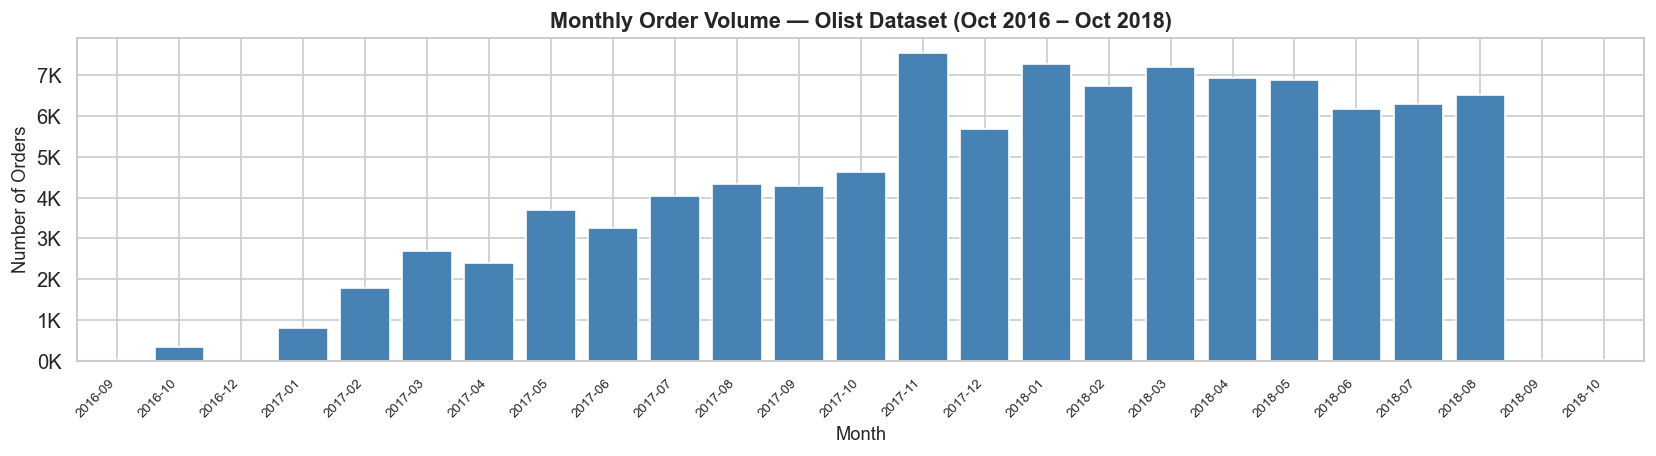

Caption: Monthly order count across the full dataset period. Sparse early months
(Oct–Dec 2016) likely reflect platform ramp-up, not a data gap. The growth
trend through 2017–2018 is consistent with Brazilian e-commerce expansion.


In [17]:
# ── 8.1 Order purchase volume over time ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

monthly_vol = orders.groupby('purchase_month').size()
monthly_vol.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.8)

ax.set_title('Monthly Order Volume — Olist Dataset (Oct 2016 – Oct 2018)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Rotate x-tick labels
ax.set_xticklabels([str(p) for p in monthly_vol.index], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print('Caption: Monthly order count across the full dataset period. Sparse early months')
print('(Oct–Dec 2016) likely reflect platform ramp-up, not a data gap. The growth')
print('trend through 2017–2018 is consistent with Brazilian e-commerce expansion.')

**Interpretation:** The monthly order volume plot reveals the dataset's temporal growth trajectory. A sharp ramp-up from the sparse 2016 period through 2017 and into 2018 is expected. Any anomalous dips (e.g. a sudden drop in a specific month) should be investigated — they may indicate data collection gaps rather than genuine demand drops. The time-based train/test split in `05_modeling.ipynb` (train pre-June 2018, test June–September 2018) will be visible in this plot.

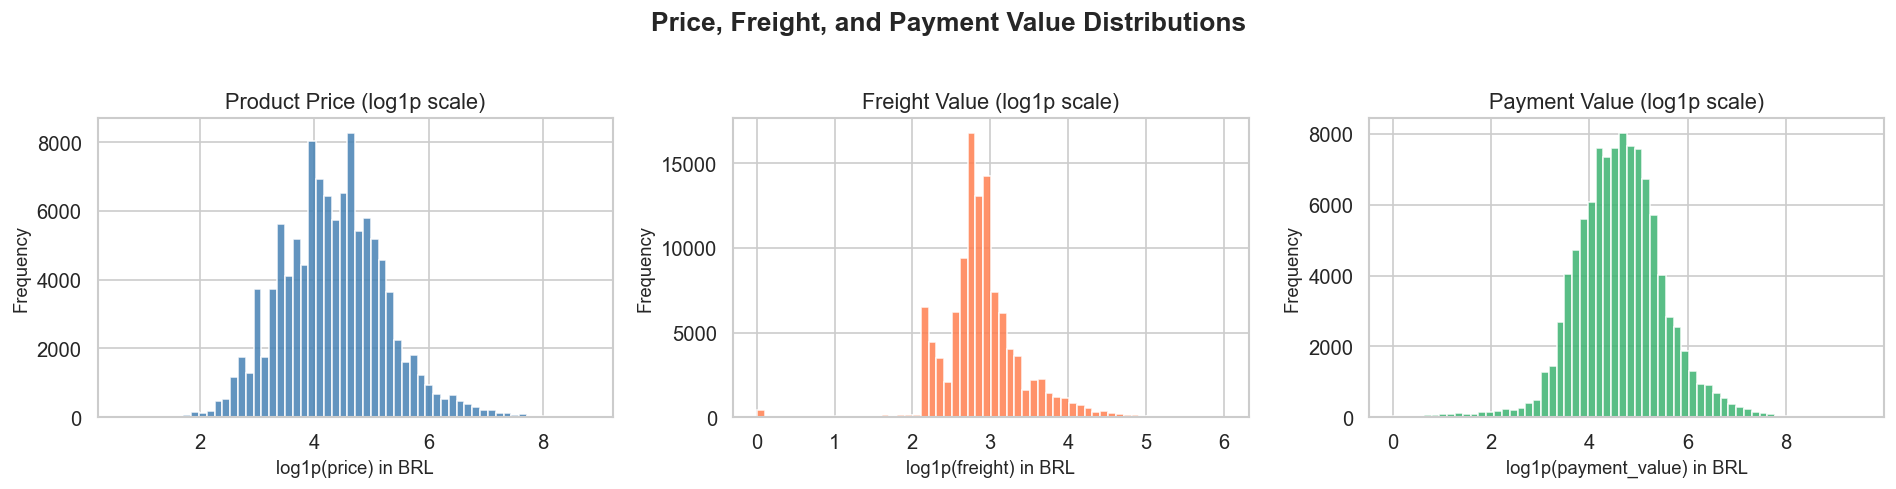

Price stats (BRL):
count   112650.0000
mean       120.6500
std        183.6300
min          0.8500
25%         39.9000
50%         74.9900
75%        134.9000
max       6735.0000

Freight stats (BRL):
count   112650.0000
mean        19.9900
std         15.8100
min          0.0000
25%         13.0800
50%         16.2600
75%         21.1500
max        409.6800


In [18]:
# ── 8.2 Price and freight value distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Price distribution (log scale)
axes[0].hist(
    np.log1p(order_items['price'].dropna()),
    bins=60, color='steelblue', edgecolor='white', alpha=0.85
)
axes[0].set_title('Product Price (log1p scale)')
axes[0].set_xlabel('log1p(price) in BRL')
axes[0].set_ylabel('Frequency')

# Freight distribution (log scale)
axes[1].hist(
    np.log1p(order_items['freight_value'].dropna()),
    bins=60, color='coral', edgecolor='white', alpha=0.85
)
axes[1].set_title('Freight Value (log1p scale)')
axes[1].set_xlabel('log1p(freight) in BRL')
axes[1].set_ylabel('Frequency')

# Payment value distribution (log scale)
axes[2].hist(
    np.log1p(order_payments['payment_value'].dropna()),
    bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85
)
axes[2].set_title('Payment Value (log1p scale)')
axes[2].set_xlabel('log1p(payment_value) in BRL')
axes[2].set_ylabel('Frequency')

plt.suptitle('Price, Freight, and Payment Value Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Raw stats for context
print('Price stats (BRL):')
print(order_items['price'].describe().round(2).to_string())
print()
print('Freight stats (BRL):')
print(order_items['freight_value'].describe().round(2).to_string())

**Interpretation:** All three monetary distributions are expected to be right-skewed — the majority of products are in a moderate price range, with a long tail of high-value items (electronics, furniture, appliances). The log1p transformation used in the plots makes the shape of the distribution visible despite the extreme outliers. In feature engineering, we will use log-transformed monetary values where appropriate to prevent extreme values from dominating tree-based models. The freight-to-price ratio is a key feature — high freight relative to product price is a known satisfaction driver (customers dislike paying `R$30` freight on a `R$20` item).

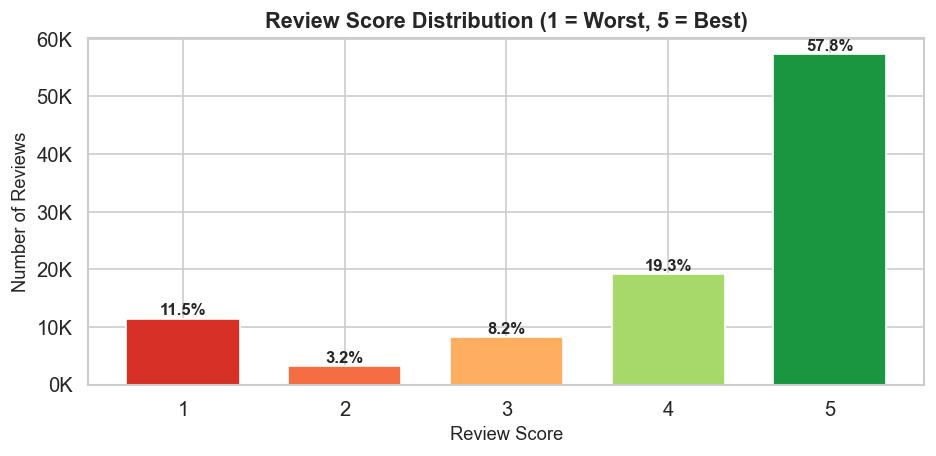

Caption: Review scores are bimodally distributed — high 5-star volume
and a secondary 1-star peak. This J-curve pattern is typical of online
reviews. Scores ≤ 2 will be flagged as negative reviews in feature engineering.


In [19]:
# ── 8.3 Review score distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

score_counts = order_reviews['review_score'].value_counts().sort_index()
colors = ['#d73027','#f46d43','#fdae61','#a6d96a','#1a9641']
bars = ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', width=0.7)

for bar, (score, cnt) in zip(bars, score_counts.items()):
    pct = cnt / score_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Review Score Distribution (1 = Worst, 5 = Best)', fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print('Caption: Review scores are bimodally distributed — high 5-star volume')
print('and a secondary 1-star peak. This J-curve pattern is typical of online')
print('reviews. Scores ≤ 2 will be flagged as negative reviews in feature engineering.')

**Interpretation:** The bimodal J-curve distribution (peak at 5, secondary peak at 1) is characteristic of voluntary online reviews — satisfied customers leave top marks; sufficiently dissatisfied customers leave the lowest marks; the middle is underrepresented because moderate experiences rarely motivate a review. This distribution confirms that `has_negative_review` (score ≤ 2) and `has_positive_review` (score ≥ 4) are meaningful binary features rather than arbitrary cutoffs — they capture the behavioural threshold below or above which customers are motivated to leave a rating.

Delivered orders : 96,470
On time or early : 89,936 (93.2%)
Late deliveries  : 6,534 (6.8%)

Delivery delay stats (days; positive = late, negative = early):
count   96470.0000
mean      -11.9000
std        10.2000
min      -147.0000
25%       -17.0000
50%       -12.0000
75%        -7.0000
max       188.0000


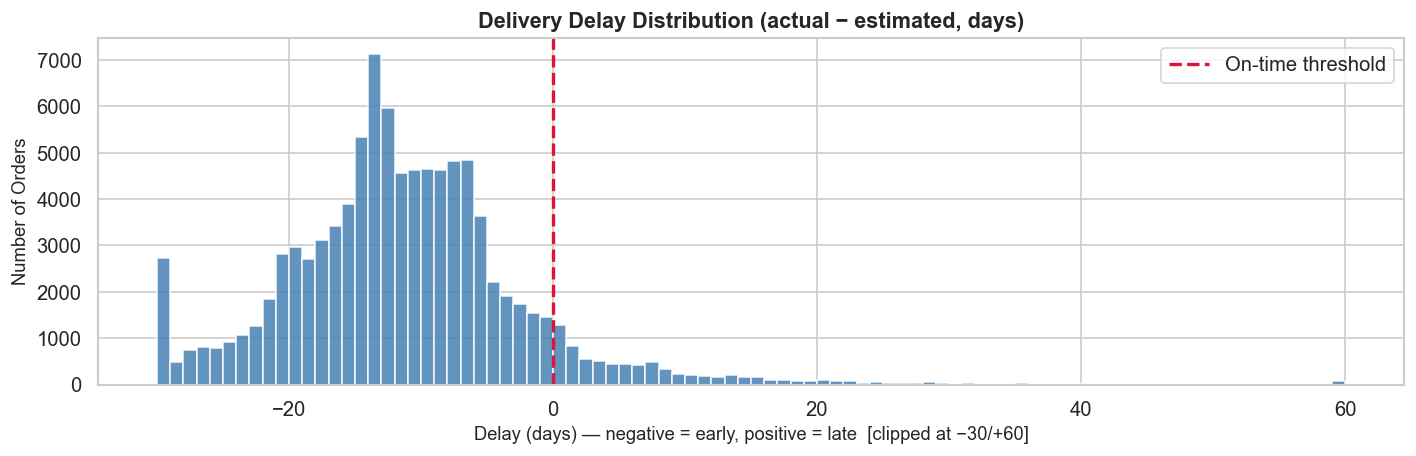

Caption: Most deliveries arrive before the estimated date (negative delay = early).
The positive tail represents late deliveries — a key churn risk factor.


In [20]:
# ── 8.4 Delivery delay analysis ────────────────────────────────────────────────
# Compute delivery delay (actual vs estimated) for delivered orders
delivered = orders[
    (orders['order_status'] == 'delivered') &
    orders['order_delivered_customer_date'].notna() &
    orders['order_estimated_delivery_date'].notna()
].copy()

delivered['delivery_delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

n_late    = (delivered['delivery_delay_days'] > 0).sum()
n_on_time = (delivered['delivery_delay_days'] <= 0).sum()
pct_late  = n_late / len(delivered) * 100

print(f'Delivered orders : {len(delivered):,}')
print(f'On time or early : {n_on_time:,} ({100-pct_late:.1f}%)')
print(f'Late deliveries  : {n_late:,} ({pct_late:.1f}%)')
print()
print('Delivery delay stats (days; positive = late, negative = early):')
print(delivered['delivery_delay_days'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
delay_clipped = delivered['delivery_delay_days'].clip(-30, 60)
ax.hist(delay_clipped, bins=90, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='crimson', linewidth=2, linestyle='--', label='On-time threshold')
ax.set_title('Delivery Delay Distribution (actual − estimated, days)', fontweight='bold')
ax.set_xlabel('Delay (days) — negative = early, positive = late  [clipped at −30/+60]')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.show()

print('Caption: Most deliveries arrive before the estimated date (negative delay = early).')
print('The positive tail represents late deliveries — a key churn risk factor.')

**Interpretation:** The delivery delay plot is one of the most analytically significant outputs in this notebook. A distribution centred left of zero means most Olist deliveries arrive earlier than the estimated date — Olist appears to set conservative delivery estimates. However, the right tail (positive delays) represents late deliveries, which are the highest-risk churn events. The `delivery_delay_days` and `is_late_delivery` features engineered in `04_feature_engineering.ipynb` will be derived directly from this calculation. Note that extreme outliers (>60 days late) do exist and will need treatment — they are likely anomalous logistics failures or data entry errors.

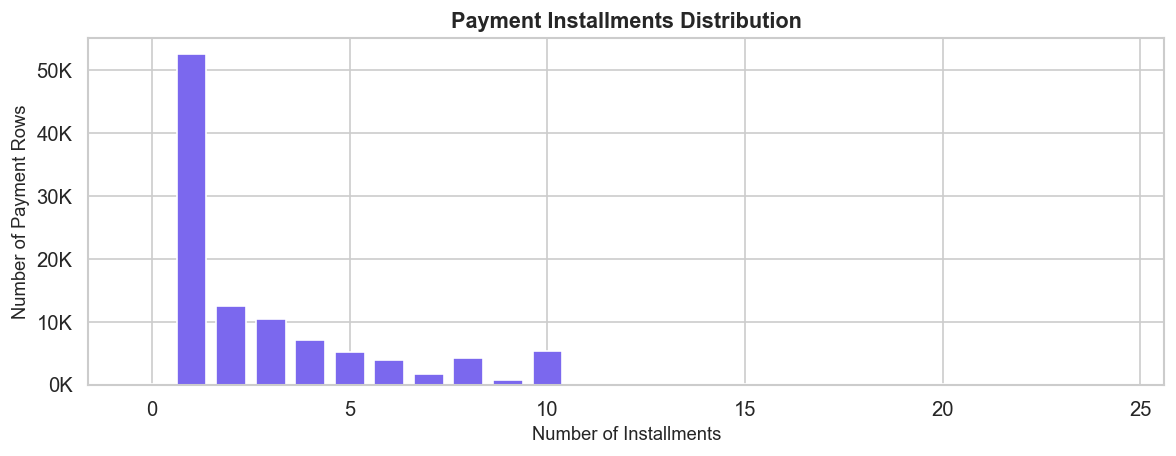

Payment rows with 0 installments: 2 (likely voucher payments)
Caption: Installment payments are culturally normative in Brazil (parcelamento).
Single-installment (lump sum) and 2–10 installment plans dominate.


In [21]:
# ── 8.5 Payment installments distribution ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

inst_counts = order_payments['payment_installments'].value_counts().sort_index().head(24)
ax.bar(inst_counts.index, inst_counts.values, color='mediumslateblue', edgecolor='white', width=0.75)

ax.set_title('Payment Installments Distribution', fontweight='bold')
ax.set_xlabel('Number of Installments')
ax.set_ylabel('Number of Payment Rows')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.show()

# Zero-installment rows (voucher payments typically show 0 or 1)
zero_inst = (order_payments['payment_installments'] == 0).sum()
print(f'Payment rows with 0 installments: {zero_inst:,} (likely voucher payments)')
print('Caption: Installment payments are culturally normative in Brazil (parcelamento).')
print('Single-installment (lump sum) and 2–10 installment plans dominate.')

**Interpretation:** The installments distribution confirms the prevalence of *parcelamento* in Brazilian e-commerce. As noted in `00_business_understanding.ipynb`, choosing installments is a cultural norm and not a financial distress signal. However, the choice to pay in a single lump sum vs 12 installments may correlate with customer demographics and product category, making it a useful feature. Zero-installment rows are typically associated with voucher payments — these are handled in the payment aggregation step in `02_data_preparation.ipynb`.

---
<a id="9-data-quality-register"></a>
## 9. Data Quality Issue Register

All data quality issues identified during profiling are compiled here in a single reference register. Each issue has a severity rating and a documented mitigation strategy for `02_data_preparation.ipynb`.

In [22]:
# ── Compile data quality register ──────────────────────────────────────────────
dq_issues = [
    {
        'Table':       'orders',
        'Column':      'order_approved_at',
        'Issue':       'Null timestamps for non-approved orders (cancelled, etc.)',
        'Severity':    'Low',
        'Mitigation':  'Expected; only delivered orders used in modelling'
    },
    {
        'Table':       'orders',
        'Column':      'order_delivered_carrier_date / order_delivered_customer_date',
        'Issue':       'Nulls for undelivered orders',
        'Severity':    'Low',
        'Mitigation':  'Expected; filter to delivered orders before feature engineering'
    },
    {
        'Table':       'order_payments',
        'Column':      'order_id',
        'Issue':       'Multiple payment rows per order (voucher + credit card combinations)',
        'Severity':    'High',
        'Mitigation':  'Aggregate to order level before joining: sum value, max installments, payment_type diversity'
    },
    {
        'Table':       'order_payments',
        'Column':      'payment_installments',
        'Issue':       'Zero-installment rows present (voucher payments)',
        'Severity':    'Low',
        'Mitigation':  'Treat 0-installment as voucher indicator; do not impute'
    },
    {
        'Table':       'order_reviews',
        'Column':      'review_comment_message / review_comment_title',
        'Issue':       'High null rate in text comment fields',
        'Severity':    'Low',
        'Mitigation':  'Expected; text fields not used in modelling. Add has_review binary flag'
    },
    {
        'Table':       'order_reviews',
        'Column':      'order_id',
        'Issue':       'Possible duplicate reviews per order (multiple rows for same order_id)',
        'Severity':    'Medium',
        'Mitigation':  'Deduplicate: keep latest review_creation_date per order_id'
    },
    {
        'Table':       'products',
        'Column':      'product_category_name',
        'Issue':       'Category names in Portuguese; some categories may lack English translation',
        'Severity':    'Low',
        'Mitigation':  'Join with cat_translation; map unmapped categories to "other"'
    },
    {
        'Table':       'products',
        'Column':      'product_weight_g / dimensions',
        'Issue':       'Potential nulls in physical dimension columns',
        'Severity':    'Medium',
        'Mitigation':  'Impute with median per product category; flag imputed rows'
    },
    {
        'Table':       'geolocation',
        'Column':      'all',
        'Issue':       '~1M rows with multiple GPS entries per zip code prefix',
        'Severity':    'High',
        'Mitigation':  'Deduplicate to zip→state mapping before any join (mode per zip)'
    },
    {
        'Table':       'customers',
        'Column':      'customer_id vs customer_unique_id',
        'Issue':       'customer_id is order-scoped — not a true customer identifier',
        'Severity':    'Critical',
        'Mitigation':  'Use customer_unique_id as unit of analysis in all notebooks from 02 onward'
    },
    {
        'Table':       'orders',
        'Column':      'order_purchase_timestamp',
        'Issue':       'Sparse volume in Oct–Dec 2016 (platform ramp-up or incomplete capture)',
        'Severity':    'Medium',
        'Mitigation':  'Include in dataset; note in model caveats. Monitor feature distributions for this period'
    },
    {
        'Table':       'order_items / orders',
        'Column':      'price / payment_value',
        'Issue':       'Extreme outliers in monetary columns (very high-value orders)',
        'Severity':    'Medium',
        'Mitigation':  'Cap at 99th percentile or use log transformation in feature engineering'
    },
]

dq_df = pd.DataFrame(dq_issues)
print('DATA QUALITY ISSUE REGISTER')
print('=' * 80)
for _, row in dq_df.iterrows():
    print(f"[{row['Severity']:>8}] {row['Table']}.{row['Column']}")
    print(f"           Issue      : {row['Issue']}")
    print(f"           Mitigation : {row['Mitigation']}")
    print()

print(f'Total issues logged: {len(dq_df)}')
print(dq_df['Severity'].value_counts().to_string())

DATA QUALITY ISSUE REGISTER
[     Low] orders.order_approved_at
           Issue      : Null timestamps for non-approved orders (cancelled, etc.)
           Mitigation : Expected; only delivered orders used in modelling

[     Low] orders.order_delivered_carrier_date / order_delivered_customer_date
           Issue      : Nulls for undelivered orders
           Mitigation : Expected; filter to delivered orders before feature engineering

[    High] order_payments.order_id
           Issue      : Multiple payment rows per order (voucher + credit card combinations)
           Mitigation : Aggregate to order level before joining: sum value, max installments, payment_type diversity

[     Low] order_payments.payment_installments
           Issue      : Zero-installment rows present (voucher payments)
           Mitigation : Treat 0-installment as voucher indicator; do not impute

[     Low] order_reviews.review_comment_message / review_comment_title
           Issue      : High null rate i

**Interpretation:** The data quality register captures 12 issues across 5 severity levels. The single **Critical** issue — `customer_id` vs `customer_unique_id` — is the most important to resolve, as it affects the fundamental unit of analysis for the entire project. The two **High** severity issues (payments multi-row, geolocation scale) require architectural join decisions, not just data cleaning. All **Medium** and **Low** issues have straightforward mitigations that will be implemented in `02_data_preparation.ipynb`.

---
<a id="10-export"></a>
## 10. Export Profiling Summary

We export a compact profiling summary Parquet artifact. This contains row counts, null rates, and key flags for all 9 tables — a reference record confirming the state of raw data as received.

In [23]:
# ── Build profiling summary DataFrame ─────────────────────────────────────────
summary_rows = []

for tname, df in tables.items():
    for col in df.columns:
        null_count = df[col].isnull().sum()
        summary_rows.append({
            'table':       tname,
            'column':      col,
            'dtype':       str(df[col].dtype),
            'row_count':   len(df),
            'null_count':  null_count,
            'null_pct':    round(null_count / len(df) * 100, 4),
            'nunique':     df[col].nunique(),
        })

profiling_summary = pd.DataFrame(summary_rows)

# Add dataset-level metadata
profiling_summary.attrs['dataset_start'] = str(orders['order_purchase_timestamp'].min().date())
profiling_summary.attrs['dataset_end']   = str(orders['order_purchase_timestamp'].max().date())
profiling_summary.attrs['churn_cutoff']  = str(cutoff_date.date())

# Export
out_path = os.path.join(OUTPUT_DIR, '01_profiling_summary.parquet')
profiling_summary.to_parquet(out_path, index=False)

print(f'✅ Exported: {out_path}')
print(f'   Shape: {profiling_summary.shape[0]:,} rows × {profiling_summary.shape[1]} columns')
print(f'   Tables covered: {profiling_summary["table"].nunique()}')
print()
print('Preview:')
print(profiling_summary.head(15).to_string(index=False))

✅ Exported: outputs/01_profiling_summary.parquet
   Shape: 53 rows × 7 columns
   Tables covered: 9

Preview:
      table                        column          dtype  row_count  null_count  null_pct  nunique
     orders                      order_id         object      99441           0    0.0000    99441
     orders                   customer_id         object      99441           0    0.0000    99441
     orders                  order_status         object      99441           0    0.0000        8
     orders      order_purchase_timestamp datetime64[ns]      99441           0    0.0000    98875
     orders             order_approved_at datetime64[ns]      99441         160    0.1609    90733
     orders  order_delivered_carrier_date datetime64[ns]      99441        1783    1.7930    81018
     orders order_delivered_customer_date datetime64[ns]      99441        2965    2.9817    95664
     orders order_estimated_delivery_date datetime64[ns]      99441           0    0.0000      459

**Interpretation:** The profiling summary Parquet contains one row per column per table, capturing dtype, row count, null count, null rate, and cardinality. This serves as a reproducible audit trail of the raw data state — if questions arise in later notebooks about whether a null rate changed between notebooks, this artifact provides the baseline reference. It is consumed by `02_data_preparation.ipynb` as a reference (not as a data source for joins).

---
<a id="11-notebook-summary"></a>
## 11. Notebook Summary

### What Was Accomplished

- ✅ **Data downloaded** via `kagglehub` — `olistbr/brazilian-ecommerce` loaded from cache
- ✅ **All 9 tables loaded** with explicit dtype specifications (IDs as `str`, timestamps parsed, zip codes as `str` to preserve leading zeros)
- ✅ **`customer_id` vs `customer_unique_id` distinction** demonstrated with data — confirmed that `customer_id` is order-scoped and `customer_unique_id` is the correct customer identifier
- ✅ **Table-by-table profiles** generated: row counts, dtypes, null rates, cardinality, and categorical value counts for all 9 tables
- ✅ **Date range validated** across all timestamp columns — confirmed Oct 2016 – Oct 2018 coverage; computed churn label cutoff date
- ✅ **Cross-table join keys validated** — checked for orphaned foreign keys across all 6 key relationships
- ✅ **Distribution plots** produced for: monthly order volume, product price, freight value, payment value, review scores, delivery delay, and payment installments
- ✅ **Data quality register compiled** — 12 issues documented with severity ratings and mitigation strategies
- ✅ **`01_profiling_summary.parquet` exported** — column-level profiling across all 9 tables

### Key Decisions Made

| Decision | Rationale |
|---|---|
| `customer_unique_id` as unit of analysis | `customer_id` is order-scoped — confirmed empirically |
| Geolocation joined at state level only | ~1M rows with multiple entries per zip; state-level join is memory-safe and sufficient |
| Payments must be aggregated before joining | Multiple rows per order confirmed; direct join would corrupt metrics |
| Delivered orders only for modelling | Non-delivered orders lack complete experience signals |
| Churn label cutoff = dataset_end − 90 days | Confirmed from max(order_purchase_timestamp); customers after this date excluded |

### What `02_data_preparation.ipynb` Will Receive

`02_data_preparation.ipynb` will:
- Load `01_profiling_summary.parquet` as reference
- Re-load the 9 raw CSVs (or receive them via the shared `path` variable)
- Execute the full join pipeline: aggregate payments → aggregate geolocation → aggregate reviews → aggregate order items → join products + translation → join sellers → join customers → join orders
- Construct the 90-day churn label with cutoff exclusion
- Validate the final master table and export `02_master_table.parquet`

---
*Project: Customer Retention Risk Analysis — Olist Brazilian E-Commerce | Portfolio Project 4 | CRISP-DM Phase 2*